In [1]:
# imports
import numpy as np
import ot  # Python Optimal Transport
import warnings
import sys

# Robust import to avoid name collisions / env errors
from rfphate import RFPHATE
from rfgap import RFGAP

from src.rfmali import RFMALI

from phate import PHATE # We need the base PHATE class for the final step
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox # For image plotting

# Sklearn imports
from sklearn.datasets import load_digits, fetch_openml
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, silhouette_score



# Silence harmless warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)


# Data loading and preprocessing

In [2]:
import numpy as np
from sklearn.datasets import load_digits, fetch_openml
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import rotate


# ------------------------------------------------------------------
# Stratified subsample with index tracking (needed to build T_true)
# ------------------------------------------------------------------
def stratified_subsample(X, y, n_samples, random_state=42, return_idx=False):
    """
    Returns:
        X_sub, y_sub, idx   (if return_idx=True)
        X_sub, y_sub        (otherwise)
    """
    if n_samples >= len(y):
        if return_idx:
            return X, y, np.arange(len(y))
        return X, y

    sss = StratifiedShuffleSplit(n_splits=1,
                                 train_size=n_samples,
                                 random_state=random_state)
    idx, _ = next(sss.split(X, y))
    if return_idx:
        return X[idx], y[idx], idx
    else:
        return X[idx], y[idx]


# ------------------------------------------------------------------
# Artificial tree data (unchanged)
# ------------------------------------------------------------------
def generate_tree_data(n_classes=10,
                       n_branches=10,
                       branch_length=100,
                       dim=50,
                       noise_level=0.1,
                       random_state=None):
    rng = np.random.default_rng(random_state)
    total = n_branches * branch_length
    X = np.zeros((total, dim))
    y = np.zeros(total, dtype=int)

    for b in range(n_branches):
        direction = rng.normal(size=dim)
        direction /= np.linalg.norm(direction)
        start = rng.normal(scale=5.0, size=dim)
        for i in range(branch_length):
            idx = b * branch_length + i
            X[idx] = start + direction * i + rng.normal(scale=noise_level, size=dim)
            y[idx] = b

    X = StandardScaler().fit_transform(X)
    return X, y


def load_artificial_tree_pair(n_samples=500,
                              n_classes=10,
                              n_branches=10,
                              branch_length=1000,
                              dim=50,
                              noise_level=0.1,
                              random_state=42):

    print("\n=== Generating Artificial Tree Domains ===")

    x_a, y_a = generate_tree_data(
        n_classes, n_branches, branch_length,
        dim, noise_level, random_state
    )
    x_b, y_b = generate_tree_data(
        n_classes, n_branches, branch_length,
        dim, noise_level, random_state+1
    )

    x_a_s, y_a_s = stratified_subsample(x_a, y_a, n_samples, random_state)
    x_b_s, y_b_s = stratified_subsample(x_b, y_b, n_samples, random_state)

    name_a = "TreeDomainA"
    name_b = "TreeDomainB"

    # No ground-truth alignment for artificial trees
    T_true = None

    print("Shapes:", x_a_s.shape, x_b_s.shape)
    return x_a_s, y_a_s, x_b_s, y_b_s, name_a, name_b, T_true


# ------------------------------------------------------------------
# Main unified pair loader (with T_true added)
# ------------------------------------------------------------------
def load_alignment_pair(data="usps/digits", n_samples=500, random_state=42):
    """
    Loads a pair of datasets with shared labels for alignment.

    Now also returns:
        T_true  -- the ground-truth matching matrix (for rotated digits)
    """

    data = data.lower()

    # ==========================================================
    # 1) OPTDIGITS ↔ USPS
    # ==========================================================
    if data in ["usps/digits", "digits/usps"]:
        print("\n=== Loading OptDigits ↔ USPS ===")

        digits = load_digits()
        x_a, y_a = digits.data.astype(float), digits.target.astype(int)
        name_a = "OptDigits"

        usps = fetch_openml("USPS", version=1, as_frame=False)
        x_b = usps.data.astype(float)
        y_b = usps.target.astype(int)
        y_b[y_b == 10] = 0
        name_b = "USPS"

        x_a = StandardScaler().fit_transform(x_a)
        x_b = StandardScaler().fit_transform(x_b)

        x_a_s, y_a_s = stratified_subsample(x_a, y_a, n_samples, random_state)
        x_b_s, y_b_s = stratified_subsample(x_b, y_b, n_samples, random_state)

        T_true = None  # no exact known matching

        return x_a_s, y_a_s, x_b_s, y_b_s, name_a, name_b, T_true


    # ==========================================================
    # 2) MNIST ↔ ROTATED MNIST  (HAS TRUE MATCHING)
    # ==========================================================
    elif data in ["digits/rotated_digits", "mnist/rotated_mnist"]:
        print("\n=== Loading MNIST ↔ Rotated-MNIST ===")

        mnist = fetch_openml("mnist_784", version=1, as_frame=False)
        x_a = mnist.data.astype(float)
        y_a = mnist.target.astype(int)
        name_a = "MNIST"

        # -------- Create rotated domain --------
        rng = np.random.default_rng(random_state)
        angles = rng.uniform(20, 80, size=len(x_a))  # try uniform with varying degrees

        x_b = np.zeros_like(x_a)
        for i, (img, ang) in enumerate(zip(x_a, angles)):
            img2d = img.reshape(28, 28)
            img_rot = rotate(img2d, angle=ang, reshape=False,
                             order=1, mode="nearest")
            x_b[i] = img_rot.ravel()

        y_b = y_a.copy()
        name_b = "RotatedMNIST"

        # -------- Scale separately --------
        x_a = StandardScaler().fit_transform(x_a)
        x_b = StandardScaler().fit_transform(x_b)

        # -------- Subsample with index tracking --------
        x_a_s, y_a_s, idx_a = stratified_subsample(x_a, y_a, n_samples,
                                                   random_state, return_idx=True)
        x_b_s, y_b_s, idx_b = stratified_subsample(x_b, y_b, n_samples,
                                                   random_state, return_idx=True)

        # -------- Build exact correspondence matrix --------
        T_true = np.zeros((len(idx_a), len(idx_b)), dtype=float)
        for i, ia in enumerate(idx_a):
            # rotated version of sample ia sits at index ia in domain B before subsampling
            matches = np.where(idx_b == ia)[0]
            if len(matches) > 0:
                T_true[i, matches[0]] = 1.0

        return x_a_s, y_a_s, x_b_s, y_b_s, name_a, name_b, T_true


    # ==========================================================
    # 3) Artificial Tree
    # ==========================================================
    elif data == "artificial_tree":
        return load_artificial_tree_pair(n_samples=n_samples,
                                         n_classes=10,
                                         n_branches=10,
                                         branch_length=2000,
                                         dim=100,
                                         noise_level=0.2,
                                         random_state=random_state)

    # ==========================================================
    # Unknown option
    # ==========================================================
    else:
        raise ValueError(f"Unknown dataset pair: {data}")


# ----------------------------------------------------------------------
# Example usage
# ----------------------------------------------------------------------

DATA = "digits/rotated_digits"
DATA = "usps/digits"


x_a_s, y_a_s, x_b_s, y_b_s, name_a, name_b, T_true = load_alignment_pair(
    data=DATA,
    n_samples=2000
)

print(f"Loaded dataset pair: {name_a} ↔ {name_b}")
print("Shapes:", x_a_s.shape, x_b_s.shape)
print("T_true shape:", None if T_true is None else T_true.shape)
print("T_true nonzeros:", None if T_true is None else T_true.sum())


=== Loading OptDigits ↔ USPS ===
Loaded dataset pair: OptDigits ↔ USPS
Shapes: (1797, 64) (2000, 256)
T_true shape: None
T_true nonzeros: None


# Model training and alignment


Starting alignment...
Fitting RFGAP on Domain A...
Fitting RFGAP on Domain B...
Building Manifold-Smoothed Posteriors (RFGAP)...
Computing Optimal Transport Plan...
Building joint affinity matrix (MALI-style fusion)...
Model fit complete.
Computing joint PHATE embedding from W_combined...
Calculating PHATE...
  Running PHATE on precomputed affinity matrix with 3797 observations.
  Calculating graph and diffusion operator...
  Calculated graph and diffusion operator in 0.06 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.74 seconds.
    Calculating KMeans...
    Calculated KMeans in 0.98 seconds.
  Calculated landmark operator in 1.72 seconds.
  Calculating optimal t...
    Automatically selected t = 16
  Calculated optimal t in 0.46 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.09 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.11 seconds.
Calculated PHATE in 4.17 seconds.
Joint embeddin

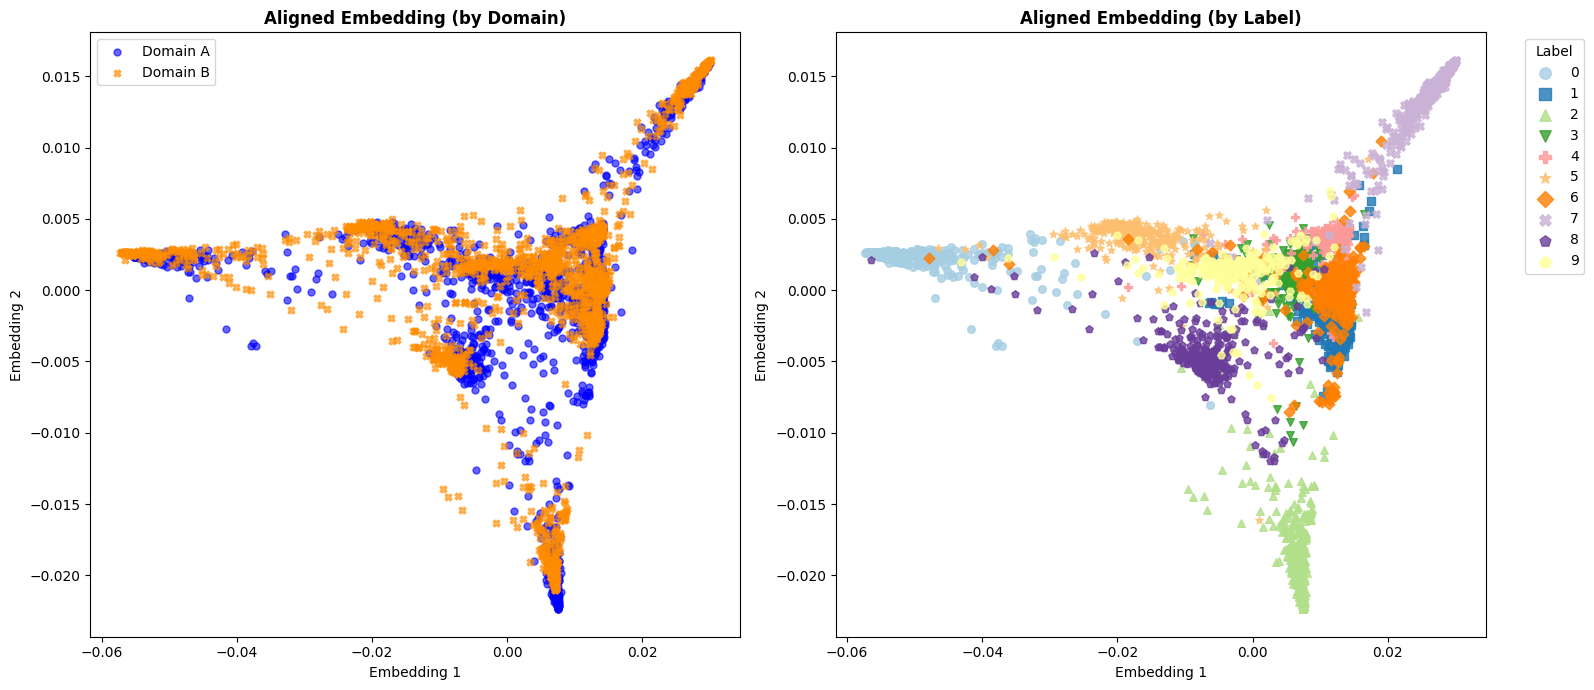


--- Quantitative Evaluation ---
1. Label Preservation (k-NN Accuracy):
  k-NN Accuracy on embedding: 0.8899 (Ideal: High)

2. Label Preservation (Silhouette Score):
  Silhouette Score (by Label): 0.4092 (Ideal: High)

3. Domain Mixing (Silhouette Score):
  Silhouette Score (by Domain): 0.0001 (Ideal: Low)

--- Interpretation ---
A good alignment shows:
  - High k-NN Acc & high Label Silhouette (labels are well-separated)
  - Low Domain Silhouette (domains are well-mixed)


In [3]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, silhouette_score

# ------------------------------------
# MODEL TRAINING & ALIGNMENT
# ------------------------------------
model = RFMALI(
    n_components=2,
    t='auto',
    n_estimators=500,
    random_state=42,
    mu=0.5,
    n_jobs=-1,
    verbose=1
)

print("\nStarting alignment...")
%time embedding = model.fit_transform(x_a_s, y_a_s, x_b_s, y_b_s)
print("Alignment complete.")

# ------------------------------------
# VISUALIZATION (Dataset-Agnostic)
# ------------------------------------
print("\n--- Visualization ---")
print("Generating plots (color-blind friendly)...")

labels_combined = np.concatenate([y_a_s, y_b_s]).astype(int)

# Generic domain names
domains_combined = np.concatenate([
    np.full(len(y_a_s), "Domain A"),
    np.full(len(y_b_s), "Domain B")
])

plt.figure(figsize=(16, 7))

# --- Plot 1: Colored by Domain ---
plt.subplot(1, 2, 1)

domain_viz = {
    "Domain A": {'color': 'blue', 'marker': 'o'},
    "Domain B": {'color': 'darkorange', 'marker': 'X'}
}

for domain in np.unique(domains_combined):
    idx = (domains_combined == domain)
    plt.scatter(
        embedding[idx, 0], embedding[idx, 1],
        c=domain_viz[domain]['color'],
        marker=domain_viz[domain]['marker'],
        label=domain,
        alpha=0.6, s=25
    )

# === OPTIONAL: TRUE MATCHING LINES (only if T_true exists) ===
if ('T_true' in globals()) and (T_true is not None):
    print("Plotting TRUE matchings (T_true).")

    T_vis = T_true
    if sparse.issparse(T_vis):
        T_vis = T_vis.A

    n_a = len(y_a_s)
    n_b = len(y_b_s)

    if T_vis.shape != (n_a, n_b):
        raise ValueError(f"T_true shape mismatch: expected {(n_a,n_b)}, got {T_vis.shape}")

    # Normalize rows
    row_sums = T_vis.sum(axis=1, keepdims=True) + 1e-12
    T_norm = T_vis / row_sums

    N_LINKS = min(100, n_a)
    subset_A = np.random.choice(n_a, size=N_LINKS, replace=False)

    for i in subset_A:
        j = np.argmax(T_norm[i])
        x1, y1 = embedding[i]
        x2, y2 = embedding[n_a + j]

        plt.plot([x1, x2], [y1, y2],
                 color="k", alpha=0.8, linewidth=2)

else:
    print("No T_true provided → skipping matching-line overlay.")

plt.title("Aligned Embedding (by Domain)", fontweight="bold")
plt.legend()
plt.xlabel("Embedding 1")
plt.ylabel("Embedding 2")

# --- Plot 2: Colored by Label ---
plt.subplot(1, 2, 2)

cmap_10_safe = plt.get_cmap("Paired")
markers_10 = ['o', 's', '^', 'v', 'P', '*', 'D', 'X', 'p', 'H']

unique_labels = np.unique(labels_combined)

for i, label in enumerate(unique_labels):
    idx = (labels_combined == label)
    marker_idx = label % len(markers_10)
    
    plt.scatter(
        embedding[idx, 0], embedding[idx, 1],
        color=cmap_10_safe(i / len(unique_labels)),
        marker=markers_10[marker_idx],
        label=str(label),
        alpha=0.8, s=30
    )

plt.title("Aligned Embedding (by Label)", fontweight="bold")
plt.legend(title="Label", markerscale=1.5, bbox_to_anchor=(1.05, 1))
plt.xlabel("Embedding 1")
plt.ylabel("Embedding 2")

plt.tight_layout()
plt.show()

# ------------------------------------
# QUANTITATIVE EVALUATION
# ------------------------------------
print("\n--- Quantitative Evaluation ---")

# 1. Label Preservation (k-NN Accuracy)
print("1. Label Preservation (k-NN Accuracy):")
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(embedding, labels_combined)
y_pred = knn.predict(embedding)
knn_acc = accuracy_score(labels_combined, y_pred)
print(f"  k-NN Accuracy on embedding: {knn_acc:.4f} (Ideal: High)")

# 2. Label Silhouette
print("\n2. Label Preservation (Silhouette Score):")
label_sil = silhouette_score(embedding, labels_combined)
print(f"  Silhouette Score (by Label): {label_sil:.4f} (Ideal: High)")

# 3. Domain Mixing Silhouette
print("\n3. Domain Mixing (Silhouette Score):")
domain_sil = silhouette_score(embedding, domains_combined)
print(f"  Silhouette Score (by Domain): {domain_sil:.4f} (Ideal: Low)")

print("\n--- Interpretation ---")
print("A good alignment shows:")
print("  - High k-NN Acc & high Label Silhouette (labels are well-separated)")
print("  - Low Domain Silhouette (domains are well-mixed)")